# PROJECT NAME- Automated Sales Reporting & Analystics 
# Section - Outlier_Detection


In [1]:
import pandas as pd
import numpy as np
import statistics as st
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt 
import openpyxl

In [2]:
# load dataset
dt3=pd.read_excel('C:\\Users\lavir\OneDrive\Pictures\Documents\Automated_Sales_Reporting\dataset\clean_dataset.xlsx')

In [3]:
dt3.select_dtypes(include='number').columns


Index(['Customer_Age', 'Delivery_Distance_KM', 'Delivery_Time_Min',
       'Order_Value_USD', 'Item_Count', 'Customer_Rating', 'Revenue_USD',
       'Profit_USD', 'Quarter', 'Churn_Risk'],
      dtype='object')

1. Numerical Columns - 'Customer_Age', 'Delivery_Distance_KM', 'Delivery_Time_Min',
       'Order_Value_USD', 'Item_Count', 'Customer_Rating', 'Revenue_USD', 'Profit_USD', 'Quarter', 'Churn_Risk'

In [4]:
# describe about every columns 
dt3.describe()

,Customer_Age,Delivery_Distance_KM,Delivery_Time_Min,Order_Value_USD,Item_Count,Customer_Rating,Revenue_USD,Profit_USD,Quarter,Churn_Risk
count,37683.000000,38047.000000,38047.000000,37002.000000,38047.000000,38047.000000,38047.000000,38047.000000,38047.000000,37683.000000
mean,47.243293,12.666573,64.128893,151.993143,7.502615,3.002707,252.555338,89.550488,2.506610,50.076265
std,37.659535,7.231141,32.350958,87.368076,4.026360,1.153437,142.453467,63.475717,1.114768,28.893304
min,-5.000000,-19.970000,-59.000000,-299.660000,1.000000,1.000000,5.000000,-19.990000,1.000000,0.000000
25%,32.000000,6.580000,37.000000,79.062500,4.000000,2.000000,129.640000,34.510000,2.000000,25.185000
50%,46.000000,12.730000,64.000000,153.000000,8.000000,3.000000,252.500000,89.710000,3.000000,50.010000
75%,60.000000,18.890000,92.000000,226.877500,11.000000,4.000000,375.060000,144.200000,3.000000,75.075000
max,999.000000,25.000000,119.000000,300.000000,14.000000,5.000000,500.000000,199.990000,4.000000,100.000000


In [5]:
# Domain Validation
# Customer Age
dt3.loc[~dt3['Customer_Age'].between(18,100),'Customer_Age']=np.nan

# Delivery_Distance_KM
dt3.loc[dt3['Delivery_Distance_KM']<0,'Delivery_Distance_KM']=np.nan

# Delivery_Time_Min
dt3.loc[dt3['Delivery_Time_Min']<0,'Delivery_Time_Min']=np.nan

# Order_Value_USD
dt3.loc[dt3['Order_Value_USD']<0,'Order_Value_USD']=np.nan

# Profit_USD
dt3.loc[dt3['Profit_USD']<0,'Profit_USD']=np.nan


IQR -(Interquartile Range) of every columns

In [6]:
# IQR 
num=dt3.select_dtypes(include='number').columns
for col in num:
 q1=dt3[col].quantile(0.25)
 q2=dt3[col].quantile(0.75)
 IQR=q2-q1
 display('=========Interquartile Range===========')
 display(f'{col} : Q1 - {q1}')
 display(f'{col} : Q2 - {q2}')
 display(f"{col}: IQR = {IQR}")


'=========Interquartile Range==========='

'Customer_Age : Q1 - 32.0'

'Customer_Age : Q2 - 60.0'

'Customer_Age: IQR = 28.0'

'=========Interquartile Range==========='

...

'Quarter: IQR = 1.0'

'=========Interquartile Range==========='

'Churn_Risk : Q1 - 25.185000000000002'

'Churn_Risk : Q2 - 75.07499999999999'

'Churn_Risk: IQR = 49.889999999999986'

You calculated IQR-based lower & upper bounds for all numeric columns.

These bounds show the normal range of values. Anything outside is an outlier.

Many columns have negative lower bounds (like Delivery_Time_Min, Order_Value_USD, Revenue_USD). But logically, these values cannot be negative → this means data errors exist.

# calculate lower & upper bounds 

In [9]:
# calculate lower & upper bound of every columns
num1=dt3.select_dtypes(include='number').columns
for col1 in num1: 
    q1=dt3[col1].quantile(0.25)
    q2=dt3[col1].quantile(0.75)
    IQR=q2-q1
    lower_bound=q1-(1.5*IQR)
    upper_bound=q2+(1.5*IQR)
    outliers = dt3[(dt3[col1] < lower_bound) | 
               (dt3[col1] > upper_bound)]
    display('====lower & upper bound')
    display(f'{col1} : Lower Bound : {q1-(1.5*IQR)}')
    display(f'{col1} : Upper Bound  : {q2+(1.5*IQR)}')

'====lower & upper bound'

'Customer_Age : Lower Bound : -10.0'

'Customer_Age : Upper Bound  : 102.0'

'====lower & upper bound'

'Delivery_Distance_KM : Lower Bound : -11.715'

...

'Quarter : Lower Bound : 0.5'

'Quarter : Upper Bound  : 4.5'

'====lower & upper bound'

'Churn_Risk : Lower Bound : -49.64999999999998'

'Churn_Risk : Upper Bound  : 149.90999999999997'

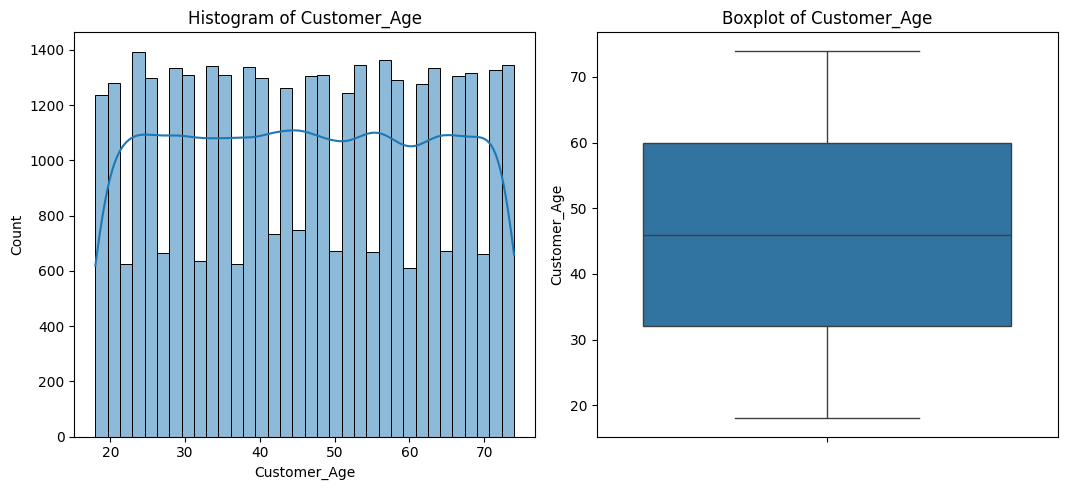

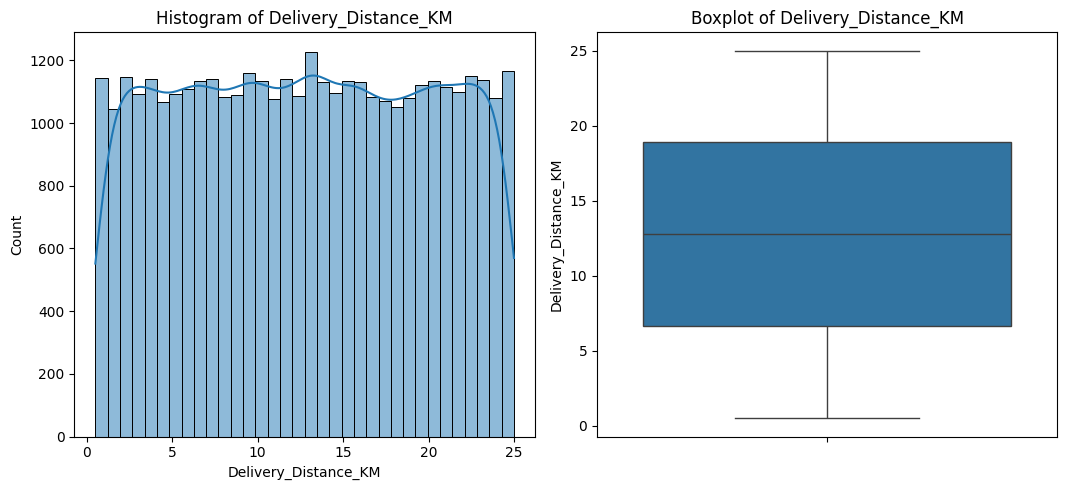

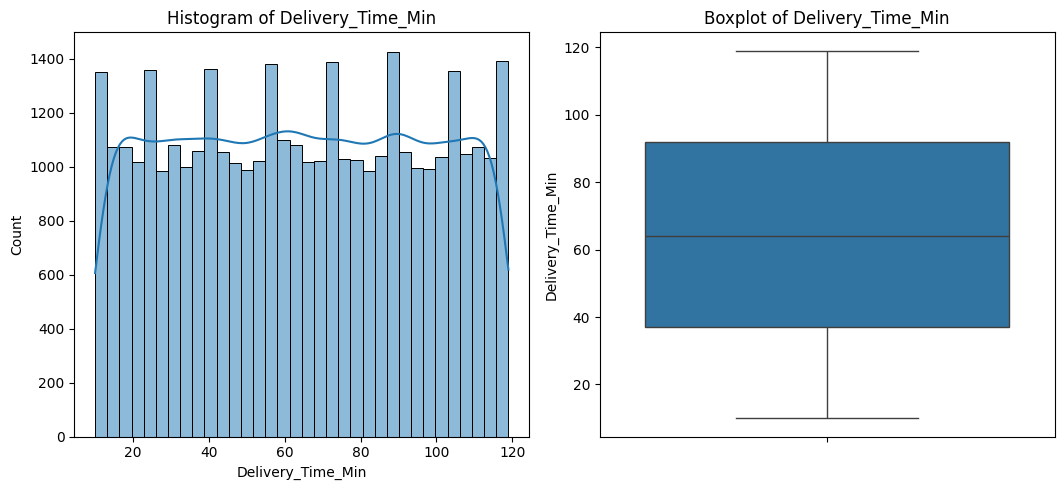

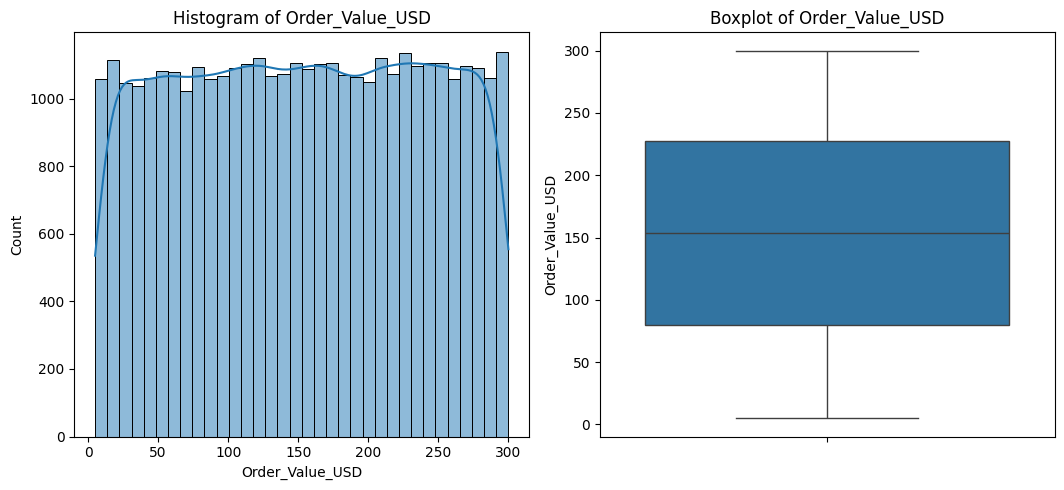

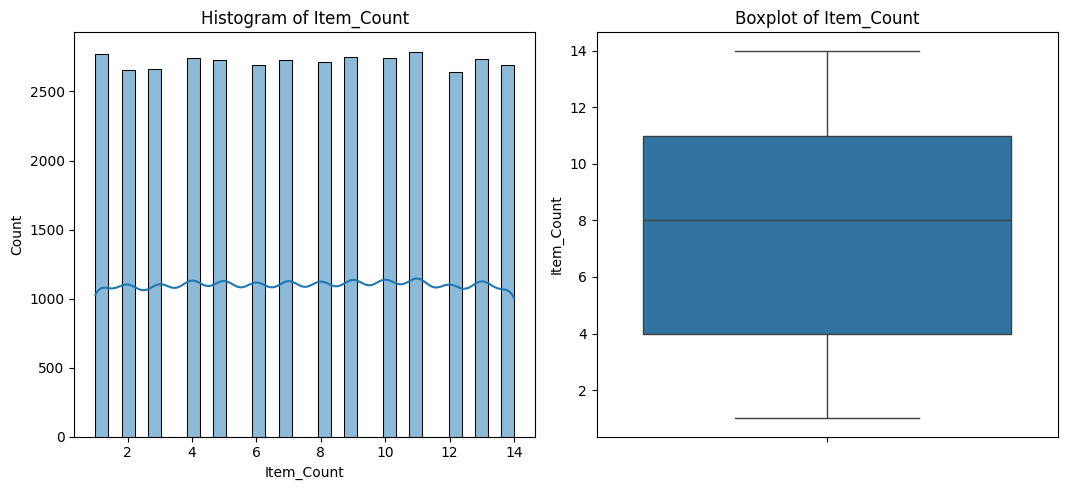

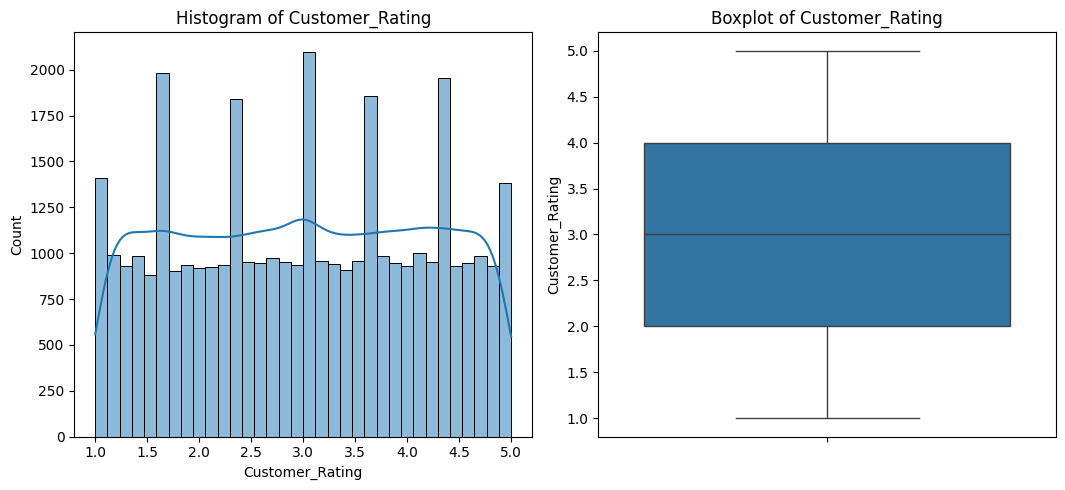

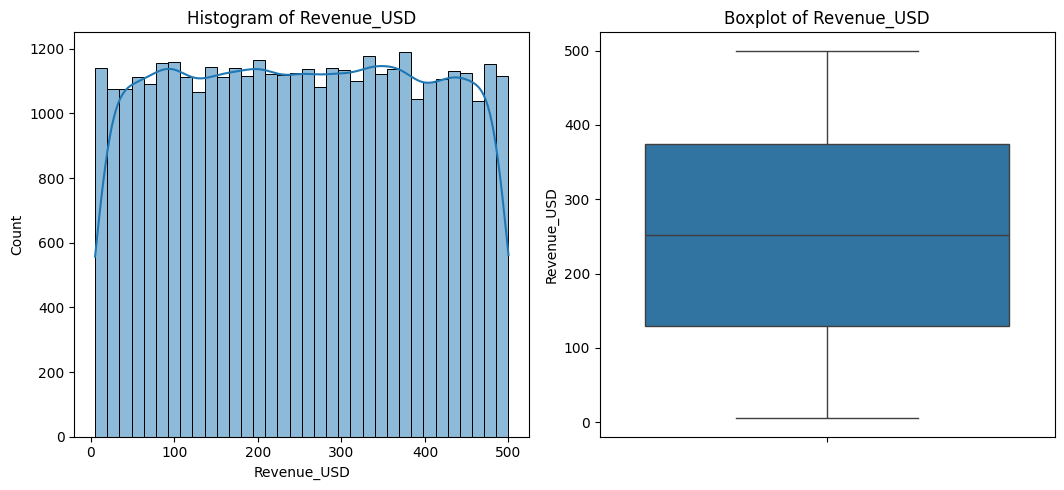

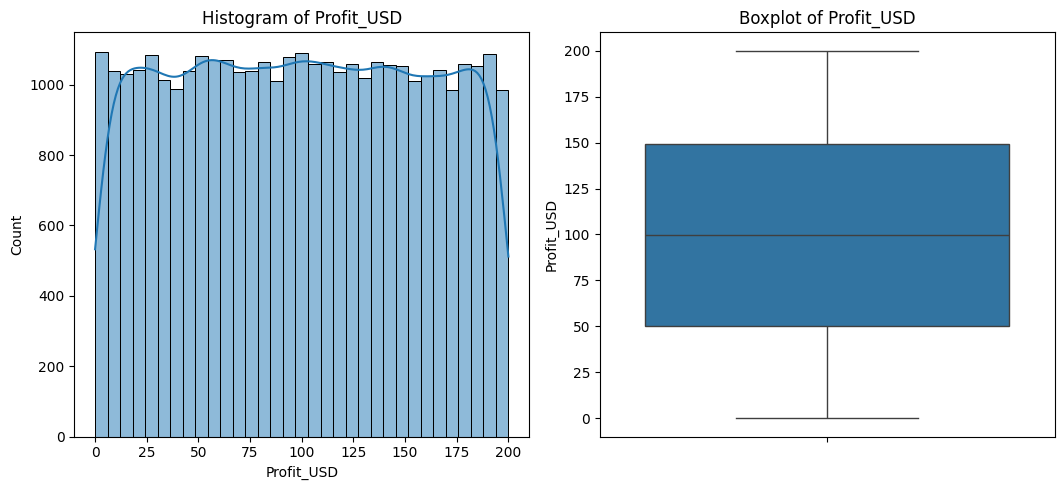

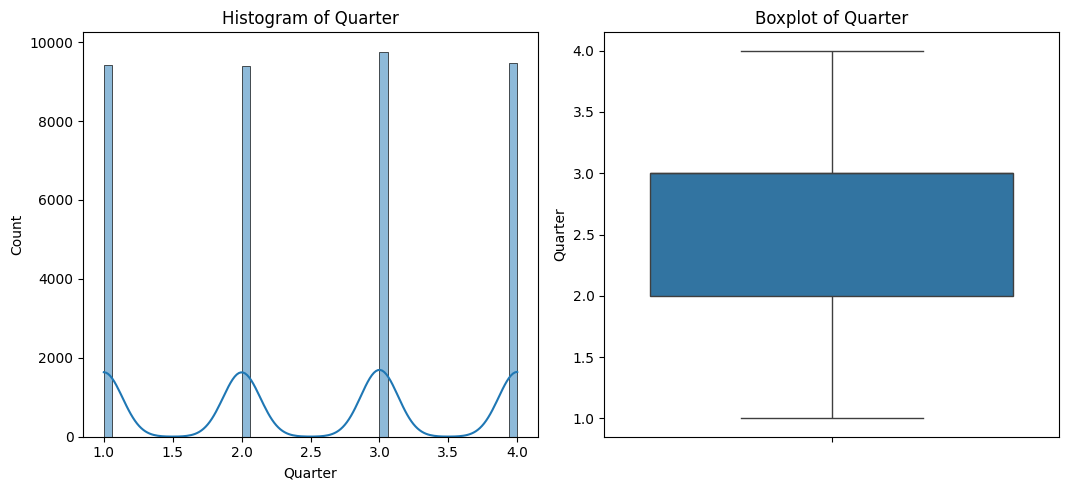

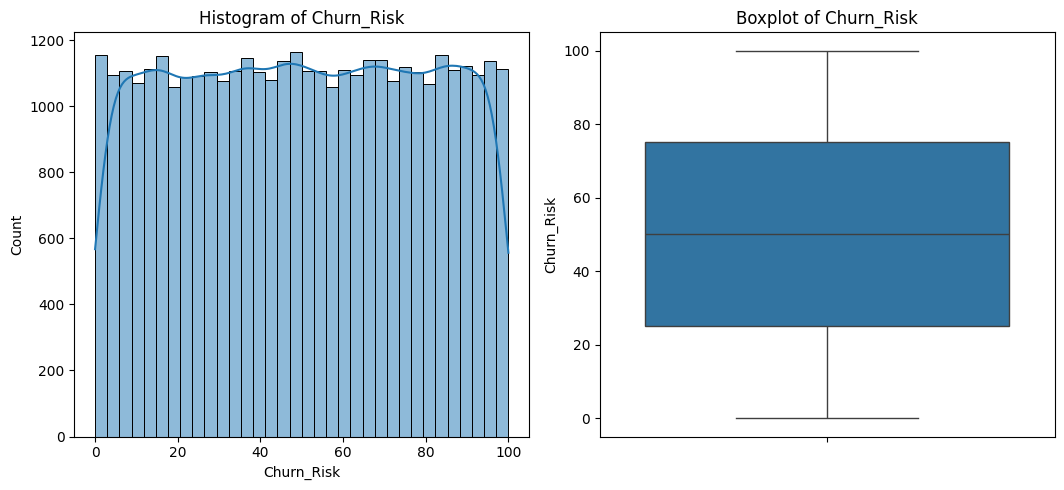

In [10]:
# detecting outliers 
num=dt3.select_dtypes(include='number').columns
for col in num:
    plt.figure(figsize=(16,5))
    plt.subplot(1,3,1)
    sns.histplot(dt3[col],kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y=dt3[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()
    